# Data Science Capstone Project
Author: Christie Chong

In [1]:
# Converted from R chunk: setup
# R: knitr::opts_chunk$set(echo = TRUE)
# In Jupyter, code is shown by default. Set some display options.
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)




<style>
div.navy1 { background-color:#686868; border-radius: 5px; padding: 20px; border-style: groove; color: #ffffff;}

</style>





In [2]:
# Converted from R chunk: load_libraries
# Original R installed/loaded: tidyverse, Hmisc, ggthemes, janitor, rpart.plot, caret, lubridate
# Python equivalents below.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance




# Introduction and learning objectives

<div class = "navy1">
The purpose of this exercise is to build an estimation engine to guide investment decisions in London house market. You will first build machine learning algorithms (and tune them) to estimate the house prices given variety of information about each property. Then, using your algorithm, you will choose 200 houses to invest in out of about 2000 houses on the market at the moment.


<b>Learning objectives</b>
 
<ol type="i">
  <li>Using different data mining algorithms for prediction.</li>
  <li>Dealing with large data sets</li>
  <li>Tuning data mining algorithms</li>
  <li>Interpreting data mining algorithms and deducing importance of variables</li>
  <li>Using results of data mining algorithms to make business decisions</li>
</ol>  
</div>

# Load data

There are two sets of data, i) training data that has the actual prices ii) out of sample data that has the asking prices. Load both data sets. 

Make sure you understand what information each column contains. Note that not all information provided might be useful in predicting house prices, but do not make any assumptions before you decide what information you use in your prediction algorithms.



In [3]:
# Converted from R chunk: read-investigate
# Read in the data
london_house_prices_2019_training = pd.read_csv("training_data_assignment_with_prices.csv")
london_house_prices_2019_out_of_sample = pd.read_csv("test_data_assignment.csv")

# Fix data types in both data sets
for _df in [london_house_prices_2019_training, london_house_prices_2019_out_of_sample]:
    if "date" in _df.columns:
        _df["date"] = pd.to_datetime(_df["date"], errors="coerce")
    # Convert string columns to categorical
    obj_cols = _df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        _df[c] = _df[c].astype("category")

# Quick look at the data
print("TRAINING INFO:")
print(london_house_prices_2019_training.info())
print("\nOUT-OF-SAMPLE INFO:")
print(london_house_prices_2019_out_of_sample.info())


TRAINING INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13998 entries, 0 to 13997
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            13998 non-null  int64         
 1   date                          13998 non-null  datetime64[ns]
 2   postcode                      13998 non-null  category      
 3   property_type                 13998 non-null  category      
 4   whether_old_or_new            13998 non-null  category      
 5   freehold_or_leasehold         13998 non-null  category      
 6   address1                      13998 non-null  category      
 7   address2                      3186 non-null   category      
 8   address3                      13998 non-null  category      
 9   town                          614 non-null    category      
 10  local_aut                     13998 non-null  category      
 11  county       

In [4]:
# Converted from R chunk: split the price data to training and testing
# Create the train/test split (75% training)
target = "price"
feature_cols = ['distance_to_station', 'water_company', 'property_type', 'whether_old_or_new', 'freehold_or_leasehold', 'latitude', 'longitude']

df = london_house_prices_2019_training.copy()
X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=42
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (10498, 7), Test size: (3500, 7)





# Visualize data 

Visualize and examine the data. What plots could be useful here? What do you learn from these visualizations?



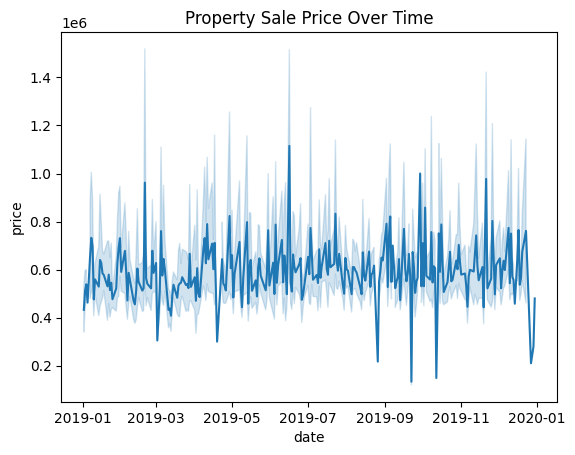

In [ ]:
df2= df.copy()

df2['month']=df2['date'].dt.month
df2.head()
df2_grouped=df2.groupby('date')['price'].mean().reset_index()

#Lineplot of date vs. property price in 2019
sns.lineplot(df2,x='date',y='price')
plt.title("Property Sale Price Over Time")
plt.show()


Text(0.5, 1.0, 'Histogram of Property Prices')

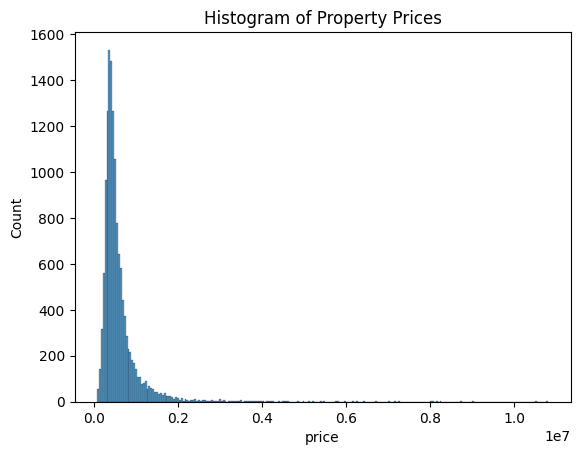

In [ ]:
#Histogram of price (no log transformation)
sns.histplot(df2,x='price')
plt.title("Histogram of Property Prices")

Text(0.5, 1.0, 'Histogram of Log Prices')

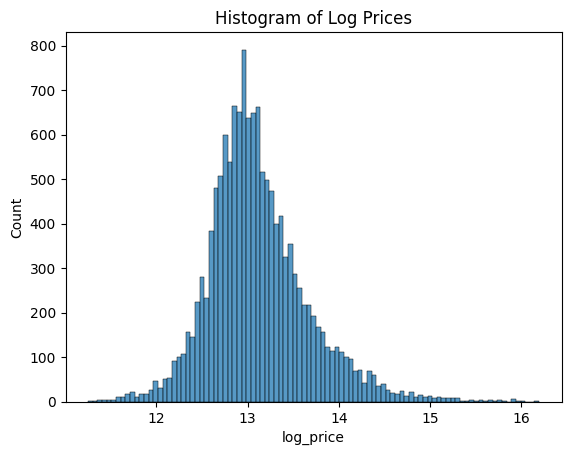

In [ ]:
#Histogram of price with log transformation
df2['log_price']=np.log(df2['price'])
sns.histplot(df2,x='log_price')
plt.title("Histogram of Log Prices")

Text(0.5, 1.0, 'Property Price Distribution by House vs. Flat')

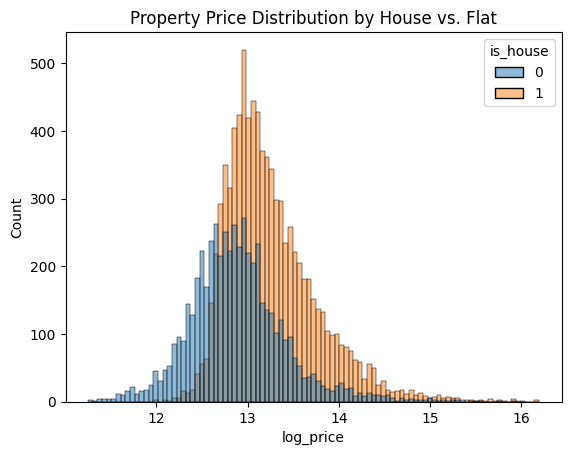

In [ ]:
#Building is_house column
#is_house is False when the property type is a flat
df2['is_house']=df2['property_type'].isin(["D","S","T"]).astype(int)

#Histogram of prices by property type
sns.histplot(df2,x='log_price',hue='is_house')
plt.title("Property Price Distribution by House vs. Flat")

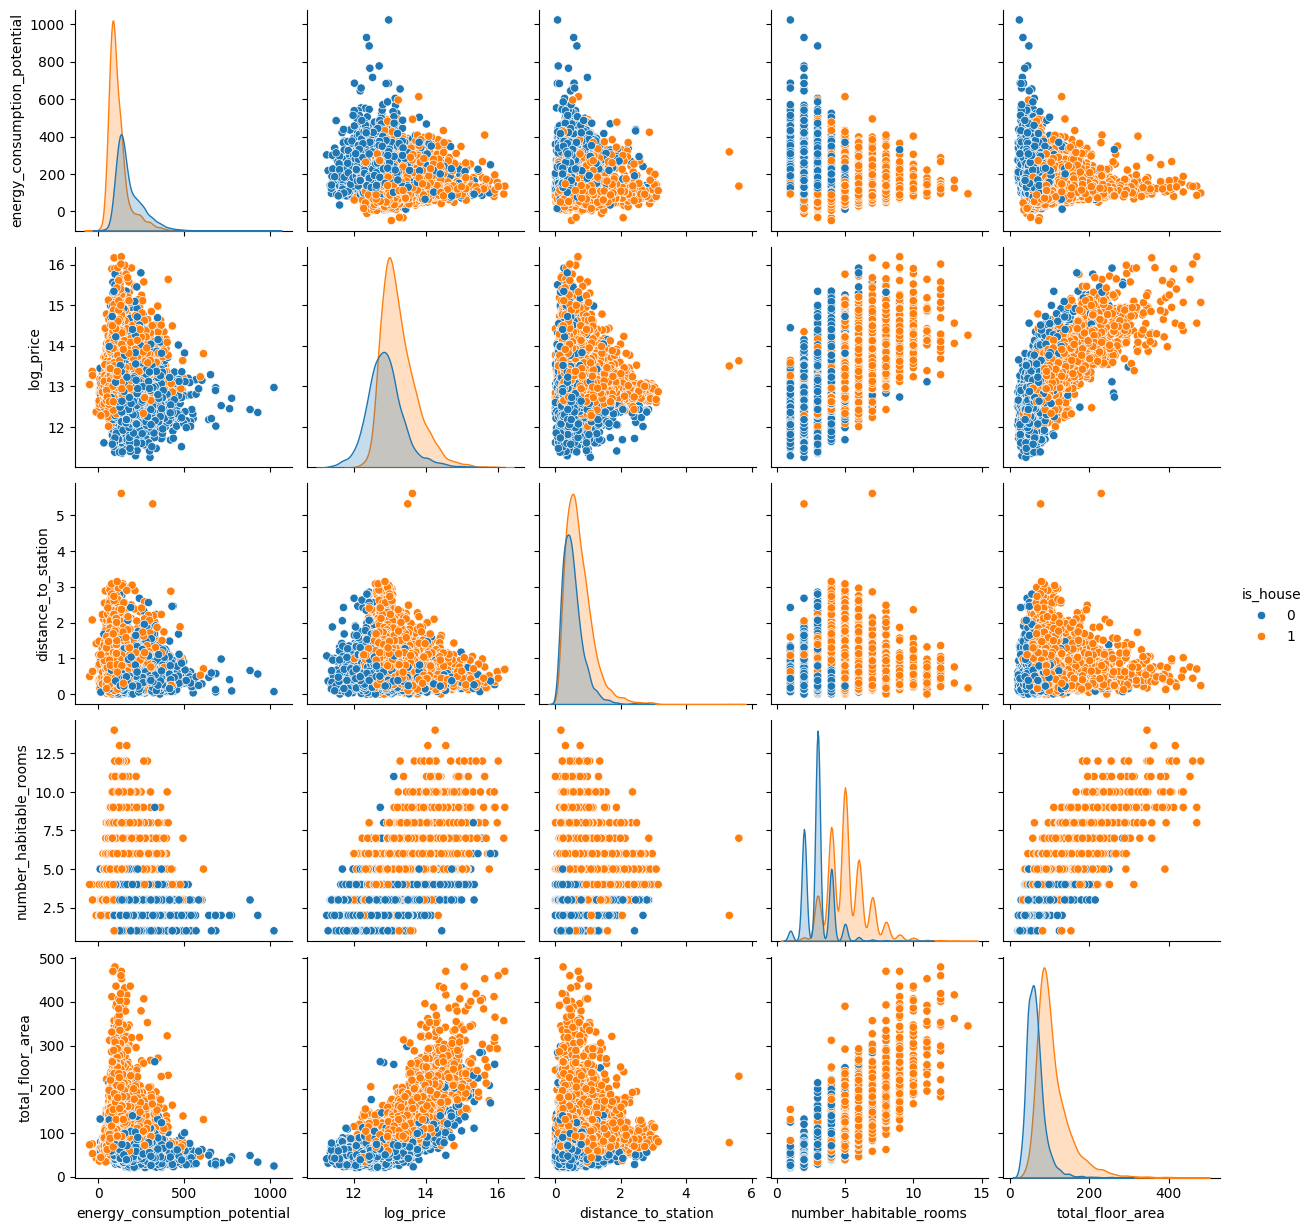

In [ ]:
#Plotting numeric features for a pairplot
numeric_features = ['energy_consumption_potential',"log_price","distance_to_station",'number_habitable_rooms','total_floor_area']

sns.pairplot(df2,hue="is_house",x_vars=numeric_features,y_vars=numeric_features)


Text(0.5, 1.0, 'Property Sale Prices by Property Type')

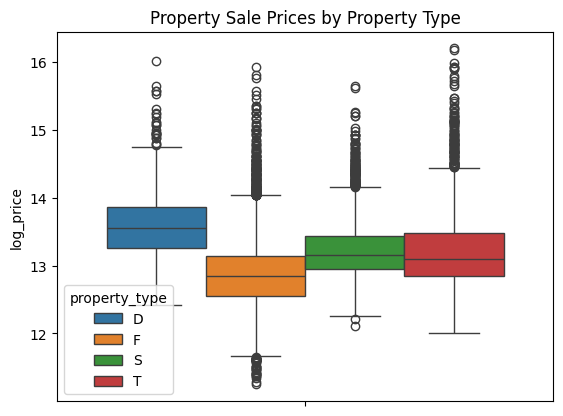

In [ ]:
#Boxplot of prices by property type 
sns.boxplot(df2,y='log_price',hue='property_type')
plt.title("Property Sale Prices by Property Type")

,k,Silhouette score,SSE
0,2,0.463353,42829.771530
1,3,0.300524,33170.598647
2,4,0.244850,27162.289618
3,5,0.125164,23499.690283
4,6,0.126288,21181.567805
5,7,0.138002,19089.488661
6,8,0.135402,17452.694665
7,9,0.122649,15990.824153
8,10,0.039358,15012.252344


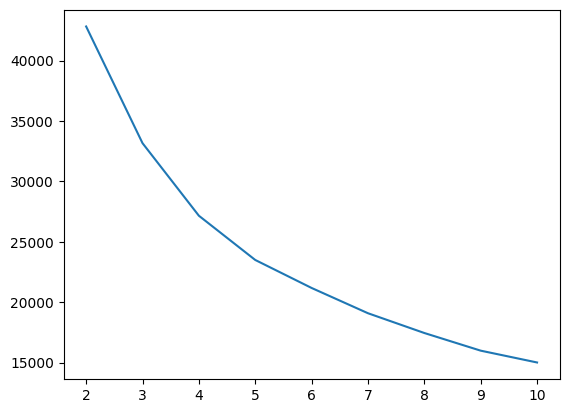

In [261]:
#Building clusters using K-mean clustering

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

#Scaling the data
scaler=StandardScaler()

#Selecting on geographic features for clustering 
df2_numeric=df2[['latitude','longitude','london_zone','distance_to_station']]

train_scaled= scaler.fit_transform(df2_numeric)

#Determining best number of clusters 
k_count=list(range(2,11))
sse=[]
sc=[]

for i in k_count:
    km=KMeans(n_clusters=i,n_init=50, random_state=1).fit(train_scaled)
    wss=km.inertia_
    sse.append(wss)

    score=silhouette_score(df2_numeric,labels=km.labels_)
    sc.append({'k':i,'Silhouette score':score,'SSE':wss})

#Displaying elbow graph
sns.lineplot(y=sse,x=k_count)
pd.DataFrame(sc)

Text(0.5, 1.0, 'Segmentation of Properties by Geographical Features')

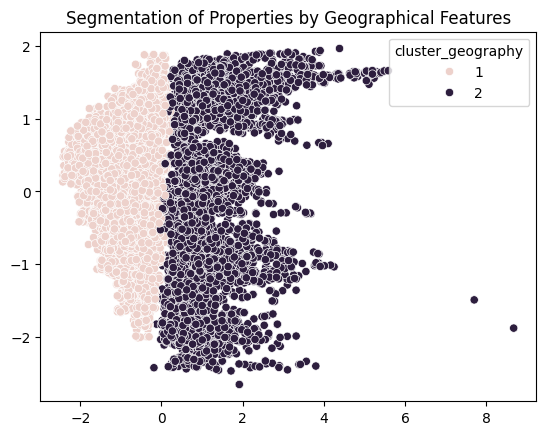

In [ ]:
#Generating clusters for geographical data
km_geography=KMeans(n_clusters=2,n_init=50, random_state=1).fit(train_scaled)

labels_km_geo=(km_geography.labels_)+1

train_scaled_df=pd.DataFrame(train_scaled)
train_scaled_df['cluster_geography']=labels_km_geo.astype('int')

#Displaying clusters using 2 PCAs
pca=PCA(n_components=2,random_state=25)

pca_kmean=pca.fit_transform(train_scaled_df.values)

sns.scatterplot(train_scaled_df,x=pca_kmean[:,0],y=pca_kmean[:,1], hue='cluster_geography')
plt.title('Segmentation of Properties by Geographical Features')

,k,Silhouette score,SSE
0,2,0.298397,48642.320937
1,3,0.306261,36301.289199
2,4,0.191683,29966.457791
3,5,0.217887,26393.882715
4,6,0.230743,23650.213457
5,7,0.206293,21595.641575
6,8,0.215318,19782.701975
7,9,0.191764,18415.198770
8,10,0.205401,17195.078779


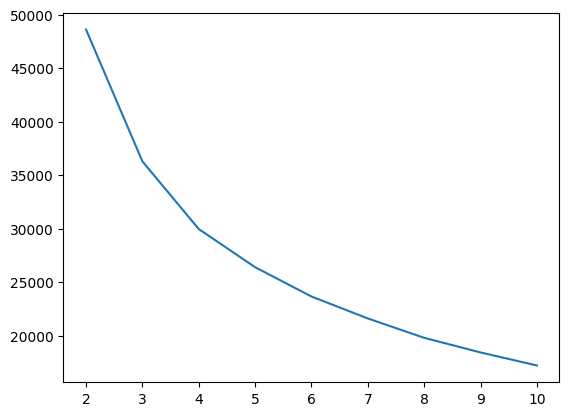

In [ ]:
#Clustering for property features 
#Scaling and selecting columns related to energy usage features 
scaler=StandardScaler()

df2_numeric=df2[['total_floor_area','co2_emissions_current','co2_emissions_potential','energy_consumption_potential','energy_consumption_current']]

train_scaled2= scaler.fit_transform(df2_numeric)

#Determining number of clusters 
k_count=list(range(2,11))
sse=[]
sc=[]

for i in k_count:
    km=KMeans(n_clusters=i,n_init=50, random_state=1).fit(train_scaled2)
    wss=km.inertia_
    sse.append(wss)

    score=silhouette_score(df2_numeric,labels=km.labels_)
    sc.append({'k':i,'Silhouette score':score,'SSE':wss})

#Displaying elbow graph
sns.lineplot(y=sse,x=k_count)
pd.DataFrame(sc)

Text(0.5, 1.0, 'Segmentation of Properties by Energy Usage')

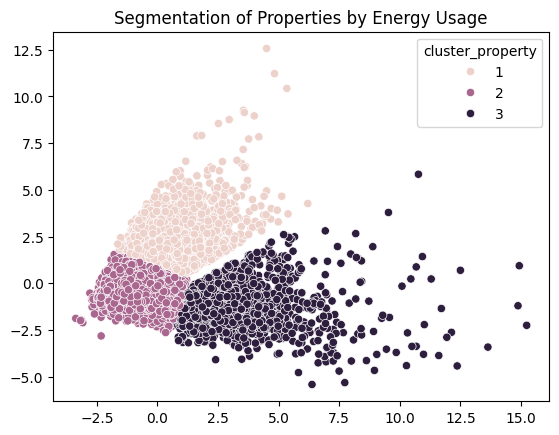

In [ ]:
#Generating clusters on data
km_energy=KMeans(n_clusters=3,n_init=50, random_state=1).fit(train_scaled)

labels_km_energy=(km_energy.labels_)+1

train_scaled_df=pd.DataFrame(train_scaled2)
train_scaled_df['cluster_property']=labels_km_energy.astype('int')

#Displaying clusters using PCA=2
pca=PCA(n_components=2,random_state=25)

pca_kmean=pca.fit_transform(train_scaled_df.values)

sns.scatterplot(train_scaled_df,x=pca_kmean[:,0],y=pca_kmean[:,1], hue='cluster_property')
plt.title("Segmentation of Properties by Energy Usage")



Estimate a correlation table between prices and other continuous variables. What do you glean from the correlation table?



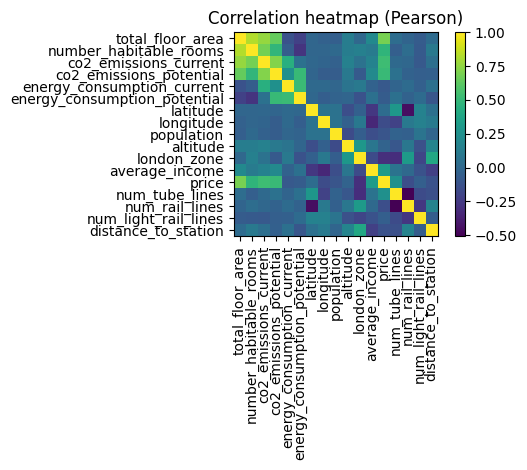

In [16]:
# Converted from R chunk: correlation table
# Compute Pearson correlations for numeric columns (drop non-numeric and ID if present)
df_corr = london_house_prices_2019_training.copy()

if "ID" in df_corr.columns:
    df_corr = df_corr.drop(columns=["ID"])

num_cols = df_corr.select_dtypes(include=[np.number]).columns
corr = df_corr[num_cols].corr(method="pearson")

# Heatmap using matplotlib (no seaborn)
plt.figure()
im = plt.imshow(corr.values, interpolation="nearest")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap (Pearson)")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()





# Fit a linear regression model

To help you get started I build a linear regression model below. I chose a subset of the features with no particular goal. You can (and should) add more variables and/or choose variable selection methods if you want.



In [17]:
# Converted from R chunk: LR model
# We'll build a scikit-learn Pipeline with preprocessing + LinearRegression
numeric_features = ["distance_to_station", "latitude", "longitude"]
categorical_features = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

lm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = (-1 * cross_val_score(lm_pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")).mean()
cv_r2 = cross_val_score(lm_pipe, X_train, y_train, cv=cv, scoring="r2").mean()
print(f"Linear Regression 5-fold CV -> RMSE: {cv_rmse:.4f}, R^2: {cv_r2:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
lm_pipe.fit(X_train, y_train)


Linear Regression 5-fold CV -> RMSE: 449332.7874, R^2: 0.1915


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


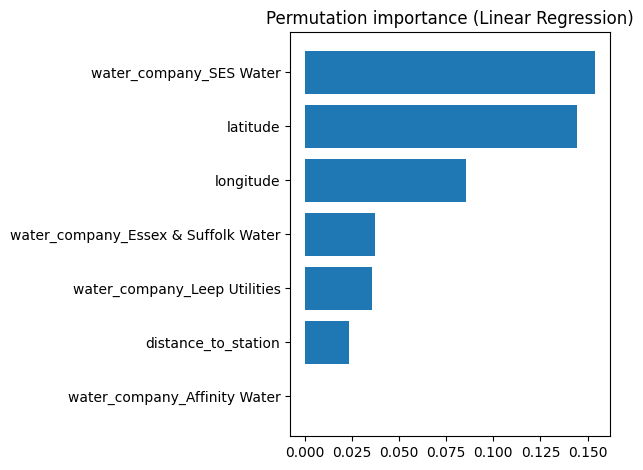

In [18]:
# Converted from R chunk: variable importance for linear model
# We'll use permutation importance on the hold-out set
r = permutation_importance(lm_pipe, X_test, y_test, n_repeats=10, random_state=42)
# Retrieve feature names after preprocessing
ohe = lm_pipe.named_steps["preprocess"].named_transformers_["cat"]
num_names = ["distance_to_station", "latitude", "longitude"]
cat_names = list(ohe.get_feature_names_out(["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]))
feature_names = num_names + cat_names

importances = r.importances_mean
# Basic bar plot
plt.figure()
order = np.argsort(importances)
plt.barh(np.array(feature_names)[order], importances[order])
plt.title("Permutation importance (Linear Regression)")
plt.tight_layout()
plt.show()




## Predict the values in testing and out of sample data

Below I use the predict function to test the performance of the model in testing data and summarize the performance of the linear regression model. How can you measure the quality of your predictions?



In [19]:
# Converted from R chunk: predictions for linear model
# Predict on the test split
predictions = lm_pipe.predict(X_test)
rmse = mean_squared_error(y_test, predictions)
rmse=np.sqrt(rmse).astype(float)
r2 = r2_score(y_test, predictions)
lr_results = {"RMSE": rmse, "Rsquare": r2}
print("lr_results:", lr_results)

# Predict on out-of-sample as well
X_oos = london_house_prices_2019_out_of_sample[["distance_to_station","water_company","property_type","whether_old_or_new","freehold_or_leasehold","latitude","longitude"]]
predictions_oos = lm_pipe.predict(X_oos)


lr_results: {'RMSE': np.float64(523465.24487014057), 'Rsquare': 0.15868859526304668}




# Fit a tree model

Next I fit a tree model using the same subset of features. Again you can (and should) add more variables and tune the parameter of your tree to find a better fit. 

Compare the performance of the linear regression model with the tree model; which one performs better? Why do you think that is the case?



In [20]:
# Converted from R chunk: LR model
# We'll build a scikit-learn Pipeline with preprocessing + LinearRegression
numeric_features = ["distance_to_station", "latitude", "longitude"]
categorical_features = ["water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

lm_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

# 5-fold CV (equivalent to caret::trainControl(method='cv', number=5))
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = (-1 * cross_val_score(lm_pipe, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error")).mean()
cv_r2 = cross_val_score(lm_pipe, X_train, y_train, cv=cv, scoring="r2").mean()
print(f"Linear Regression 5-fold CV -> RMSE: {cv_rmse:.4f}, R^2: {cv_r2:.4f}")

# Fit on full training set to get a final model (caret refits on all training data)
lm_pipe.fit(X_train, y_train)


Linear Regression 5-fold CV -> RMSE: 449332.7874, R^2: 0.1915


,steps,"[('preprocess', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Other algorithms

Use at least two other algorithms to predict prices. Don't forget to tune the parameters of these algorithms. And then compare the performances of your algorithms to linear regression and trees.

In [ ]:

#Implementing clusters on data set prior to test-train split

energy_features=['total_floor_area','co2_emissions_current','co2_emissions_potential','energy_consumption_potential','energy_consumption_current']
geo_features=['latitude','longitude','london_zone','distance_to_station']

df_scaled_energy=scaler.fit_transform(df[energy_features])
df_scaled_geo=scaler.fit_transform(df[geo_features])

#Getting energy related clusters
km_energy=KMeans(n_clusters=3,n_init=50, random_state=1).fit(df_scaled_energy)
km_energy_labels=(km_energy.labels_+1).astype(int)

df['cluster_energy']=km_energy_labels

#Getting geography related clusters
km_geo=KMeans(n_clusters=2,n_init=50, random_state=1).fit(df_scaled_geo)
km_geo_labels=(km_geo.labels_+1).astype(int)

df['cluster_geo']=km_geo_labels


In [22]:
#Overall test train split
target = "price"
feature_cols = ['cluster_energy','cluster_geo','co2_emissions_current','co2_emissions_potential','district','average_income','total_floor_area','num_tube_lines','energy_consumption_potential','london_zone','distance_to_station', 'water_company', 'property_type', 'whether_old_or_new', 'freehold_or_leasehold', 'latitude', 'longitude','number_habitable_rooms','current_energy_rating']

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=42
)

In [ ]:
#Preprocess only pipeline
numeric_features = ['co2_emissions_current','co2_emissions_potential','average_income','number_habitable_rooms','energy_consumption_potential',"num_tube_lines","distance_to_station", "latitude", "longitude","london_zone", "total_floor_area"]
categorical_features = ['cluster_energy','cluster_geo','district','current_energy_rating',"water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

from sklearn.preprocessing import FunctionTransformer,PolynomialFeatures

y_transformer = FunctionTransformer(
    func=np.log1p,       # Natural log: y -> ln(y)
    inverse_func=np.expm1, # Exponential: ln(y) -> y
    check_inverse=True,
    validate=True
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features), #Apply standard scaler to numeric features
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features), #apply one-hot encoding to categoricals 
    ],
    remainder="drop",
)

lm_pipe = Pipeline(steps=[
    ("preprocess", preprocess)
])

In [ ]:
#Custom preprocessor function 
#This custom preprocessor allows for customisation of columns used in the pipeline
#Takes the input of a list of numerical and categorical variables to be used in the model

def create_custom_preprocessor(num_var,cat_var, interact_var=None):
    numeric= [col for col in num_var if col in numeric_features] 
    categorical=[ col for col in cat_var if col in categorical_features]

    transformer=[]
    if numeric:
        transformer.append(("num", StandardScaler(), numeric)) #scale numeric variables
    if categorical:
        transformer.append(("cat", OneHotEncoder(handle_unknown="ignore"), categorical)) #one-hot encoding for categorical
    
    if interact_var: #option for interaction variables 
        for i,group in enumerate(interact_var):
            name=f'interaction group {i}'

            interaction_step = Pipeline([
                ("select", ColumnTransformer([("keep", "passthrough", group)])),
                ("std", StandardScaler()), # Scale before multiplying
                ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)) #combine interaction variables
            ])
            transformer.append((name, interaction_step, group))
    
    return ColumnTransformer(
        transformers=transformer,
        remainder="drop"
    )

In [ ]:
#Implementing custom model pipelines
#Each model implemented uses its own set of numerical and categorical variables 

from sklearn.linear_model import Lasso

#Lasso model pipeline
lasso_num=['total_floor_area','london_zone','average_income','co2_emissions_current','co2_emissions_potential']
lasso_cat=[ "property_type", "freehold_or_leasehold",'cluster_geo','cluster_energy']

lasso_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=lasso_num, 
        cat_var=lasso_cat
    )),
    ("regressor", Lasso(alpha=0.01, random_state=1,max_iter=5000))
])


#Elastic Net model pipeline for houses
from sklearn.linear_model import ElasticNet
en_num = ['co2_emissions_current','co2_emissions_potential','average_income','energy_consumption_potential',"num_tube_lines","distance_to_station","london_zone", "total_floor_area"]
en_cat = ['cluster_geo','cluser_energy','current_energy_rating', "property_type", "freehold_or_leasehold"]

en_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=en_num, 
        cat_var=en_cat
    )),
    ("regressor", ElasticNet(alpha=0.001, l1_ratio=0,random_state=101,max_iter=5000))
])

#KNN model pipeline for geographical data
from sklearn.neighbors import KNeighborsRegressor

knn_num=['average_income','longitude','latitude','distance_to_station','london_zone']
knn_cat=['district','property_type','cluster_geo']

knn_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=knn_num, 
        cat_var=knn_cat
    )),
    ("regressor", KNeighborsRegressor(n_neighbors=5,n_jobs=-1))
])

#KNN model pipeline for physical property features

knn_num2=['co2_emissions_current','co2_emissions_potential','number_habitable_rooms',"total_floor_area"]
knn_cat2=['current_energy_rating',"water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

knn_pipe2= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=knn_num2, 
        cat_var=knn_cat2
    )),
    ("regressor", KNeighborsRegressor(n_neighbors=5,n_jobs=-1))
])

#KNN all model
knn_num3=['average_income','number_habitable_rooms',"distance_to_station","london_zone", "total_floor_area"]
knn_cat3=['cluster_energy','cluster_geo','current_energy_rating', "property_type", "whether_old_or_new"]

knn_pipe3= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=knn_num3, 
        cat_var=knn_cat3
    )),
    ("regressor", KNeighborsRegressor(n_neighbors=5,n_jobs=-1))
])

#Random forest model pipeline for overview 
from sklearn.ensemble import RandomForestRegressor

rf_num = ['co2_emissions_current','co2_emissions_potential','average_income','number_habitable_rooms','energy_consumption_potential',"num_tube_lines","distance_to_station", "latitude", "longitude","london_zone", "total_floor_area"]
rf_cat = ['cluster_energy','cluster_geo','district','current_energy_rating',"water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

rf_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=rf_num, 
        cat_var=rf_cat
    )),
    ("regressor", RandomForestRegressor(n_estimators=100, max_depth=3,min_samples_split=2,random_state=1001))
])


#Gradient Boosting model pipeline
from sklearn.ensemble import GradientBoostingRegressor
gbm_num = ['co2_emissions_current','co2_emissions_potential','average_income','number_habitable_rooms','energy_consumption_potential',"num_tube_lines","distance_to_station", "latitude", "longitude","london_zone", "total_floor_area"]
gbm_cat = ['cluster_energy','cluster_geo','district','current_energy_rating',"water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

gbm_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=gbm_num, 
        cat_var=gbm_cat
    )),
    ("regressor", GradientBoostingRegressor(n_estimators=100, learning_rate=0.01,min_samples_split=2,max_depth=3,random_state=10001))
])

#XGBoost pipeline
from xgboost import XGBRegressor

xgb_num = ['co2_emissions_current','co2_emissions_potential','average_income','number_habitable_rooms','energy_consumption_potential',"num_tube_lines","distance_to_station", "latitude", "longitude","london_zone", "total_floor_area"]
xgb_cat = ['cluster_energy','cluster_geo','district','current_energy_rating',"water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

xgb_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=xgb_num, 
        cat_var=xgb_cat
    )),
    ("regressor",XGBRegressor(n_estimators=100, learning_rate=0.01,max_depth=3,tree_method='exact' ,random_state=100001))
])

#Catboost pipeline- take categorical variables only
from catboost import CatBoostRegressor
cat_num=[]
cat_cat=['cluster_energy','cluster_geo','district','current_energy_rating',"water_company", "property_type", "whether_old_or_new", "freehold_or_leasehold"]

cat_pipe= Pipeline(steps=[
    ("preprocess", create_custom_preprocessor(
        num_var=cat_num, 
        cat_var=cat_cat
    )),
    ("regressor",CatBoostRegressor(learning_rate=0.01,depth=3,random_state=1000001))
])

In [ ]:
#Transform y variables using log1p
#fitting and transforming y train
Ytrain2=y_transformer.fit_transform(y_train.values.reshape(-1, 1))

#Transforming y test using the log transformation fitted on y train to avoid data leakage 
Ytest2=y_transformer.transform(y_test.values.reshape(-1,1))

#feature_names = preprocess.get_feature_names_out()



In [ ]:
#Defining a function to print model performance metrics 

def linear_metrics(model,X_test,Y_test):
    #Predict price using model
    pred=model.predict(X_test)

    #Get RMSE
    rmse=mean_squared_error(Y_test,pred)
    rmse=np.sqrt(rmse).astype(float)

    #Get R squared
    r2 = r2_score(Y_test, pred)

    #Gather metrics as a dictionary 
    lr_results = {"RMSE": rmse, "Rsquare": r2}

    #Print dictionary
    print("lr_results:", lr_results)

In [ ]:
#Lasso model 

#Defining lasso parameters to tune
lasso_grid={'regressor__alpha':np.arange(0.01,0.5,0.01)}

#Grid search to tune parameters, scoring on RMSE 
lasso=GridSearchCV(
    lasso_pipe,
    param_grid=lasso_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

#Fitting lasso model 
lasso.fit(X_train, Ytrain2)

#Getting best estimator 
lasso_best=lasso.best_estimator_

lasso_model = lasso_best.named_steps['regressor']

#Getting coefficients 
coef=pd.DataFrame({'Features':lasso_best.named_steps['preprocess'].get_feature_names_out(),'Coefficients':lasso_model.coef_,'Absolute_Coefficient': np.abs(lasso_model.coef_)})

#Get model performance on test set
linear_metrics(lasso_best,X_test,Ytest2)

coef.sort_values(by='Absolute_Coefficient',ascending=False)




lr_results: {'RMSE': np.float64(0.28781996778925606), 'Rsquare': 0.7281380923802536}


,Features,Coefficients,Absolute_Coefficient
0,num__total_floor_area,3.205005e-01,3.205005e-01
1,num__london_zone,-1.818402e-01,1.818402e-01
2,num__average_income,1.254232e-01,1.254232e-01
9,cat__freehold_or_leasehold_F,8.910838e-02,8.910838e-02
6,cat__property_type_F,-6.476857e-02,6.476857e-02
3,num__co2_emissions_current,1.566064e-02,1.566064e-02
10,cat__freehold_or_leasehold_L,-1.470536e-15,1.470536e-15
4,num__co2_emissions_potential,0.000000e+00,0.000000e+00
5,cat__property_type_D,0.000000e+00,0.000000e+00
7,cat__property_type_S,0.000000e+00,0.000000e+00


In [ ]:
#Elastic Net model 
#Determining parameters to tune
param_en={'regressor__alpha':np.arange(0.01,0.5,0.01),
                'regressor__l1_ratio':[0,0.5,1]}

#Grid search on parameters 
en_model=GridSearchCV(
    en_pipe,
    param_grid=param_en,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

#Fitting the model
en_model.fit(X_train, Ytrain2)

#Getting the best model
en_best=en_model.best_estimator_
en_model=en_best.named_steps['regressor']

#Print performance metrics
linear_metrics(en_best,X_test,Ytest2)




python(94844) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94845) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94846) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94847) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94848) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94849) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94850) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(94851) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


lr_results: {'RMSE': np.float64(0.27361038752402245), 'Rsquare': 0.7543189373679291}


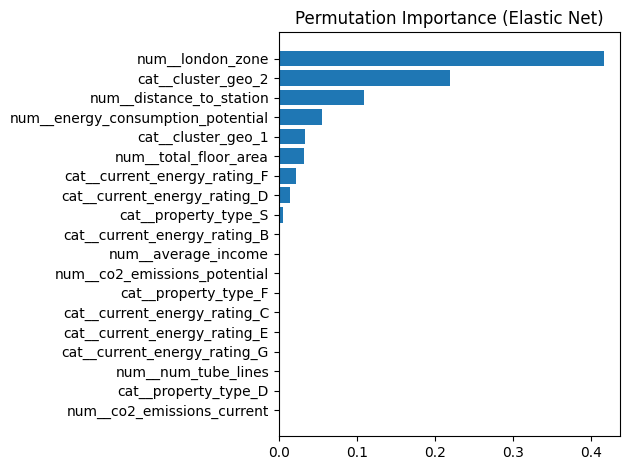

In [ ]:
#Feature importance plot for elastic net
r = permutation_importance(en_best, X_test, Ytest2, n_repeats=10, random_state=42)
# Retrieve feature names after preprocessing
feature_names=en_best.named_steps['preprocess'].get_feature_names_out()

importances = r.importances_mean
# Basic bar plot
plt.figure()
order = np.argsort(importances)
plt.barh(np.array(feature_names)[order], importances[order])
plt.title("Permutation Importance (Elastic Net)")
plt.tight_layout()
plt.show()

In [ ]:
#KNN model on geography related features

#Defining parameters to tune
knn_grid={'regressor__n_neighbors':range(5,51,1)}

#Grid search on parameters
knn=GridSearchCV(
    knn_pipe,
    param_grid=knn_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

#Fitting the model 
knn.fit(X_train, Ytrain2)

knn_best=knn.best_estimator_

#Performance metrics
linear_metrics(knn_best,X_test,Ytest2)


KNeighborsRegressor(n_jobs=-1, n_neighbors=10)
lr_results: {'RMSE': np.float64(0.33155055555263935), 'Rsquare': 0.6392502495084822}


In [ ]:
#KNN model with physical property features
#Parameters to tune
knn_grid2={'regressor__n_neighbors':range(5,51,1)}

knn2=GridSearchCV(
    knn_pipe2,
    param_grid=knn_grid2,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

knn2.fit(X_train, Ytrain2)

knn_best2=knn2.best_estimator_

linear_metrics(knn_best2,X_test,Ytest2)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['co2_emissions_current',
                                                   'co2_emissions_potential',
                                                   'number_habitable_rooms',
                                                   'total_floor_area']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['current_energy_rating',
                                                   'water_company',
                                                   'property_type',
                                                   'whether_old_or_new',
                                                   'freehold_or_leasehold'])])),
                ('regressor', KNeighborsRegressor(n_jobs=-1, n_neighbors=21))

In [33]:
#KNN model with all features
knn_grid3={'regressor__n_neighbors':range(5,51,1)}

knn3=GridSearchCV(
    knn_pipe3,
    param_grid=knn_grid3,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

knn3.fit(X_train, Ytrain2)

knn_best3=knn3.best_estimator_


linear_metrics(knn_best3,X_test,Ytest2)


lr_results: {'RMSE': np.float64(0.27371905555638226), 'Rsquare': 0.7541237475611663}


In [ ]:
#Tree based model

#Getting parameters to tune
param_grid_rf={
    'regressor__n_estimators':[100,200],
    'regressor__max_depth':[10,20],
    'regressor__min_samples_split':[2,5]
}

#Grid search on parameters
rf=GridSearchCV(
    rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

#Fitting the tree model
rf.fit(X_train,Ytrain2)

#Getting the best model
rf_best=rf.best_estimator_
rf_model=rf_best.named_steps['regressor']

#Performance metrics
linear_metrics(rf_best,X_test,Ytest2)

#Extracting feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': rf_best.named_steps['preprocess'].get_feature_names_out(),
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index()

feature_importance_rf.head(10)


lr_results: {'RMSE': np.float64(0.21704812672459897), 'Rsquare': 0.8453967556581875}


,index,Feature,Importance
0,10,num__total_floor_area,0.566660
1,9,num__london_zone,0.153121
2,2,num__average_income,0.067577
3,8,num__longitude,0.054882
4,7,num__latitude,0.032671
5,3,num__number_habitable_rooms,0.019136
6,6,num__distance_to_station,0.015208
7,0,num__co2_emissions_current,0.014286
8,4,num__energy_consumption_potential,0.011477
9,1,num__co2_emissions_potential,0.009043


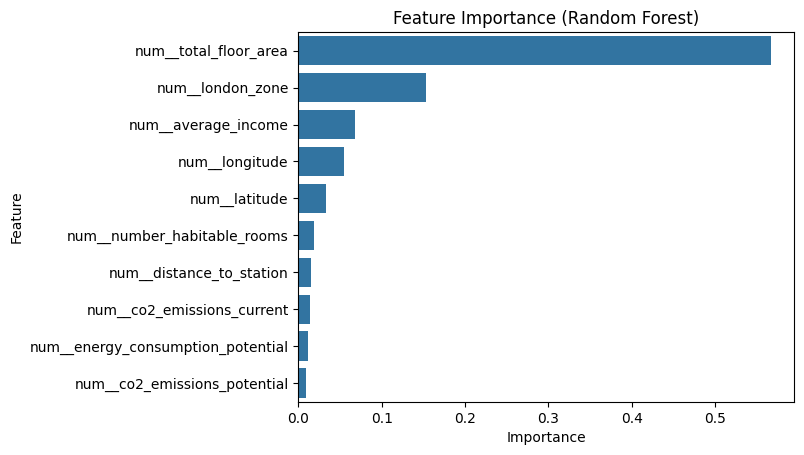

In [ ]:
#Barplot for feature importance 
sns.barplot(data=feature_importance_rf.head(10),x='Importance',y='Feature')
plt.title('Feature Importance (Random Forest)')
plt.show()

In [ ]:
#Gradient Boosting model

#Parameters to tune, slow learner with lower learning rate 
gbm_grid={'regressor__n_estimators':[100,200,250],
          'regressor__learning_rate':[0.01,0.05],
          'regressor__max_depth':[3,7,15],
          'regressor__min_samples_split':[10,15]
          }

#Grid search on parameters
gbm=GridSearchCV(
    gbm_pipe,
    param_grid=gbm_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

#Fitting model
gbm.fit(X_train,Ytrain2)

#Getting best model
gbm_best=gbm.best_estimator_
gbm_model=gbm_best.named_steps['regressor']

#Performance metrics
linear_metrics(gbm_best,X_test,Ytest2)

#Extracting feature importance
feature_importance_gbm = pd.DataFrame({
    'Feature': gbm_best.named_steps['preprocess'].get_feature_names_out(),
    'Importance': gbm_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index()

feature_importance_gbm.head(10)

GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_split=15,
                          n_estimators=250, random_state=10001)
lr_results: {'RMSE': np.float64(0.2094158216473949), 'Rsquare': 0.85607855866617}


,index,Feature,Importance
0,10,num__total_floor_area,0.584094
1,9,num__london_zone,0.157542
2,2,num__average_income,0.063281
3,8,num__longitude,0.057572
4,7,num__latitude,0.034414
5,3,num__number_habitable_rooms,0.016876
6,0,num__co2_emissions_current,0.009001
7,6,num__distance_to_station,0.008224
8,61,cat__property_type_F,0.007696
9,66,cat__freehold_or_leasehold_F,0.007110


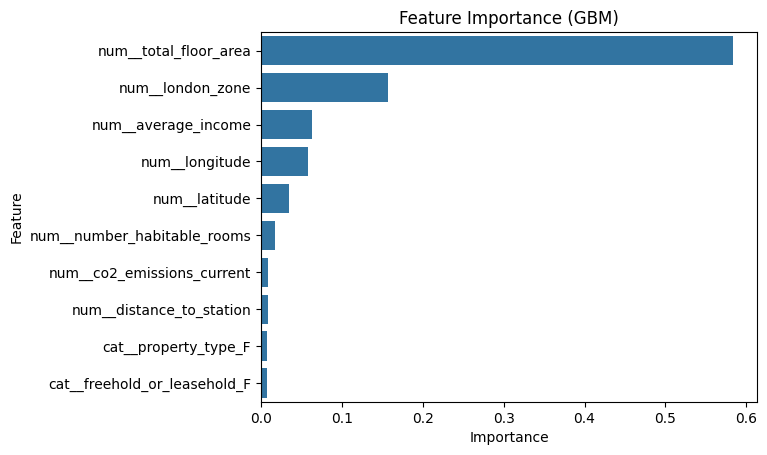

In [ ]:
#Feature importance bar plot
sns.barplot(data=feature_importance_gbm.head(10),x='Importance',y='Feature')
plt.title('Feature Importance (GBM)')
plt.show()

In [ ]:
#Gradient Boosting model (No log transformation)

gbm2=GridSearchCV(
    gbm_pipe,
    param_grid=gbm_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

gbm2.fit(X_train,y_train)

gbm_best2=gbm2.best_estimator_
gbm_model2=gbm_best2.named_steps['regressor']


linear_metrics(gbm_best2,X_test,y_test)


feature_importance_gbm2 = pd.DataFrame({
    'Feature': gbm_best2.named_steps['preprocess'].get_feature_names_out(),
    'Importance': gbm_model2.feature_importances_
}).sort_values('Importance', ascending=False).reset_index()

feature_importance_gbm2.head(10)

GradientBoostingRegressor(learning_rate=0.05, max_depth=7, min_samples_split=15,
                          n_estimators=250, random_state=10001)
lr_results: {'RMSE': np.float64(234629.48237542706), 'Rsquare': 0.8309768323014265}


,index,Feature,Importance
0,10,num__total_floor_area,0.543015
1,9,num__london_zone,0.253079
2,8,num__longitude,0.051266
3,2,num__average_income,0.035770
4,7,num__latitude,0.023078
5,35,cat__district_Kensington and Chelsea,0.022619
6,6,num__distance_to_station,0.009004
7,1,num__co2_emissions_potential,0.008947
8,0,num__co2_emissions_current,0.007992
9,48,cat__district_Westminster,0.005178


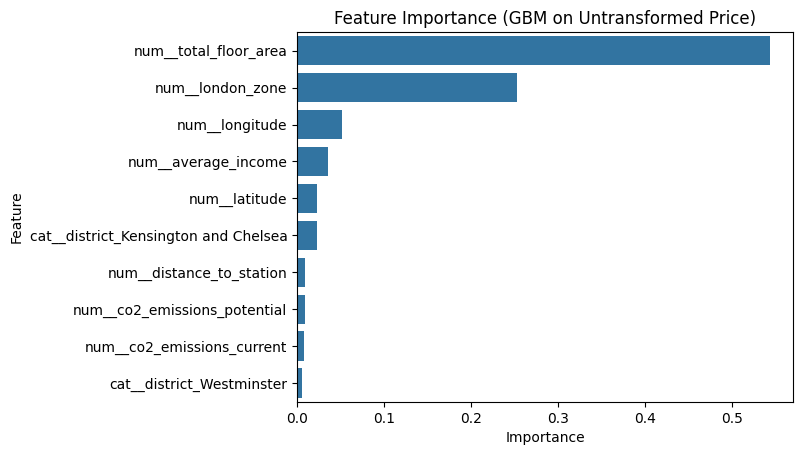

In [ ]:
#Feature importance barplot for GBM on untransformed price
sns.barplot(data=feature_importance_gbm2.head(10),x='Importance',y='Feature')
plt.title('Feature Importance (GBM on Untransformed Price)')
plt.show()

In [ ]:
#XGBoost model
#Tuning parameters
xgb_grid={'regressor__n_estimators':[100,200,250],
          'regressor__learning_rate':[0.01,0.05],
          'regressor__max_depth':[3,7,15],
          }

#Grid search 
xgb=GridSearchCV(
    xgb_pipe,
    param_grid=xgb_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

#Fitting the model
xgb.fit(X_train,Ytrain2)

#getting the best estimator
xgb_best=xgb.best_estimator_
xgb_model=xgb_best.named_steps['regressor']

#performance metrics
linear_metrics(xgb_best,X_test,Ytest2)

#Extracting feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': xgb_best.named_steps['preprocess'].get_feature_names_out(),
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index()

feature_importance_xgb.head(10)

python(89713) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


python(89714) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


lr_results: {'RMSE': np.float64(0.20839080097675552), 'Rsquare': 0.8574840056331905}


,index,Feature,Importance
0,10,num__total_floor_area,0.257261
1,9,num__london_zone,0.224660
2,66,cat__freehold_or_leasehold_F,0.044944
3,14,cat__cluster_geo_1,0.032020
4,35,cat__district_Kensington and Chelsea,0.029449
5,2,num__average_income,0.023468
6,61,cat__property_type_F,0.023029
7,42,cat__district_Richmond upon Thames,0.020788
8,59,cat__water_company_Thames Water,0.019166
9,3,num__number_habitable_rooms,0.018438


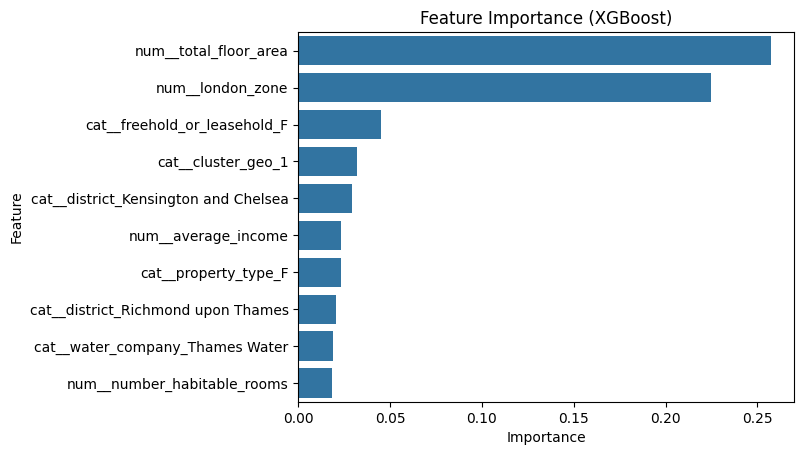

In [ ]:
#Plotting feature importance
sns.barplot(data=feature_importance_xgb.head(10),x='Importance',y='Feature')
plt.title('Feature Importance (XGBoost)')
plt.show()

In [ ]:
#Catboost model
#Parameters to tune
cat_grid={
          'regressor__learning_rate':[0.01,0.05],
          'regressor__depth':[3,7]
          }

#Conduct grid search
cat=GridSearchCV(
    cat_pipe,
    param_grid=cat_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1)

#Fitting the model
cat.fit(X_train,Ytrain2)

#Getting best estimtator
cat_best=cat.best_estimator_
cat_model=cat_best.named_steps['regressor']

#Perofrmance metrics
linear_metrics(cat_best,X_test,Ytest2)

#Extracting feature importance
feature_importance_cat = pd.DataFrame({
    'Feature': cat_best.named_steps['preprocess'].get_feature_names_out(),
    'Importance': cat_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index()

feature_importance_cat.head(10)

python(89784) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


0:	learn: 0.5429384	total: 71.3ms	remaining: 1m 11s
0:	learn: 0.5445082	total: 71.4ms	remaining: 1m 11s
0:	learn: 0.5390468	total: 71.4ms	remaining: 1m 11s
1:	learn: 0.5420224	total: 72.3ms	remaining: 36.1s
1:	learn: 0.5404986	total: 72.5ms	remaining: 36.2s
1:	learn: 0.5366185	total: 72.5ms	remaining: 36.2s
2:	learn: 0.5380927	total: 73.2ms	remaining: 24.3s
2:	learn: 0.5342332	total: 73.5ms	remaining: 24.4s
2:	learn: 0.5395813	total: 73.5ms	remaining: 24.4s
3:	learn: 0.5357237	total: 74.3ms	remaining: 18.5s
3:	learn: 0.5318847	total: 74.4ms	remaining: 18.5s
3:	learn: 0.5375315	total: 74.5ms	remaining: 18.5s
4:	learn: 0.5295659	total: 75.2ms	remaining: 15s
4:	learn: 0.5333939	total: 75.2ms	remaining: 15s
4:	learn: 0.5351474	total: 75.5ms	remaining: 15s
5:	learn: 0.5272891	total: 76.1ms	remaining: 12.6s
5:	learn: 0.5310972	total: 76.1ms	remaining: 12.6s
5:	learn: 0.5328071	total: 76.6ms	remaining: 12.7s
6:	learn: 0.5250477	total: 76.8ms	remaining: 10.9s
6:	learn: 0.5288360	total: 77.1ms	

python(89787) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


688:	learn: 0.3375258	total: 921ms	remaining: 416ms
709:	learn: 0.3379951	total: 913ms	remaining: 373ms
711:	learn: 0.3358815	total: 906ms	remaining: 367ms
689:	learn: 0.3374823	total: 922ms	remaining: 414ms
712:	learn: 0.3358400	total: 907ms	remaining: 365ms
710:	learn: 0.3379585	total: 915ms	remaining: 372ms
690:	learn: 0.3374514	total: 923ms	remaining: 413ms
713:	learn: 0.3357976	total: 908ms	remaining: 364ms
691:	learn: 0.3374052	total: 924ms	remaining: 411ms
714:	learn: 0.3357598	total: 910ms	remaining: 363ms
711:	learn: 0.3379088	total: 917ms	remaining: 371ms
692:	learn: 0.3373592	total: 925ms	remaining: 410ms
712:	learn: 0.3378653	total: 918ms	remaining: 370ms
715:	learn: 0.3357269	total: 912ms	remaining: 362ms
693:	learn: 0.3373245	total: 926ms	remaining: 408ms
713:	learn: 0.3378208	total: 919ms	remaining: 368ms
694:	learn: 0.3372805	total: 928ms	remaining: 407ms
716:	learn: 0.3356930	total: 913ms	remaining: 360ms
714:	learn: 0.3377820	total: 920ms	remaining: 367ms
695:	learn: 

python(89788) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


94:	learn: 0.4243193	total: 179ms	remaining: 1.71s
886:	learn: 0.3024857	total: 976ms	remaining: 124ms
864:	learn: 0.3030487	total: 971ms	remaining: 152ms
880:	learn: 0.3048467	total: 976ms	remaining: 132ms
865:	learn: 0.3030350	total: 972ms	remaining: 150ms
95:	learn: 0.4237329	total: 181ms	remaining: 1.7s
881:	learn: 0.3048371	total: 978ms	remaining: 131ms
887:	learn: 0.3024723	total: 977ms	remaining: 123ms
96:	learn: 0.4230999	total: 182ms	remaining: 1.69s
866:	learn: 0.3030221	total: 974ms	remaining: 149ms
882:	learn: 0.3048291	total: 979ms	remaining: 130ms
888:	learn: 0.3024651	total: 978ms	remaining: 122ms
97:	learn: 0.4225484	total: 183ms	remaining: 1.69s
867:	learn: 0.3030082	total: 975ms	remaining: 148ms
883:	learn: 0.3048269	total: 981ms	remaining: 129ms
889:	learn: 0.3024576	total: 980ms	remaining: 121ms
868:	learn: 0.3030033	total: 976ms	remaining: 147ms
98:	learn: 0.4220095	total: 185ms	remaining: 1.68s
884:	learn: 0.3048119	total: 982ms	remaining: 128ms
890:	learn: 0.3024

python(89789) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


0:	learn: 0.5417150	total: 58.8ms	remaining: 58.7s
312:	learn: 0.3159809	total: 530ms	remaining: 1.16s
1:	learn: 0.5392664	total: 61ms	remaining: 30.4s
101:	learn: 0.3952042	total: 530ms	remaining: 4.67s
2:	learn: 0.5368518	total: 62.2ms	remaining: 20.7s
114:	learn: 0.3879752	total: 529ms	remaining: 4.07s
562:	learn: 0.3456080	total: 933ms	remaining: 724ms
313:	learn: 0.3158731	total: 533ms	remaining: 1.16s
3:	learn: 0.5344744	total: 63.4ms	remaining: 15.8s
4:	learn: 0.5321361	total: 64.8ms	remaining: 12.9s
5:	learn: 0.5298310	total: 66.4ms	remaining: 11s
314:	learn: 0.3158277	total: 536ms	remaining: 1.17s
6:	learn: 0.5275617	total: 67.8ms	remaining: 9.62s
563:	learn: 0.3455600	total: 939ms	remaining: 726ms
7:	learn: 0.5253276	total: 69.2ms	remaining: 8.58s
564:	learn: 0.3455002	total: 940ms	remaining: 724ms
8:	learn: 0.5234078	total: 70.5ms	remaining: 7.77s
102:	learn: 0.3944916	total: 541ms	remaining: 4.71s
565:	learn: 0.3454526	total: 942ms	remaining: 722ms
315:	learn: 0.3157849	tot

python(89790) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


966:	learn: 0.3001977	total: 2.06s	remaining: 70.2ms
637:	learn: 0.3387376	total: 1.59s	remaining: 905ms
967:	learn: 0.3001885	total: 2.06s	remaining: 68ms
638:	learn: 0.3386783	total: 1.6s	remaining: 902ms
357:	learn: 0.3323900	total: 2.1s	remaining: 3.77s
968:	learn: 0.3001863	total: 2.06s	remaining: 65.9ms
30:	learn: 0.4727019	total: 228ms	remaining: 7.13s
329:	learn: 0.3330877	total: 2.11s	remaining: 4.29s
639:	learn: 0.3386376	total: 1.6s	remaining: 899ms
969:	learn: 0.3001782	total: 2.06s	remaining: 63.7ms
640:	learn: 0.3386002	total: 1.6s	remaining: 896ms
31:	learn: 0.4711613	total: 231ms	remaining: 6.98s
970:	learn: 0.3001696	total: 2.06s	remaining: 61.6ms
358:	learn: 0.3323085	total: 2.11s	remaining: 3.76s
641:	learn: 0.3385670	total: 1.6s	remaining: 893ms
971:	learn: 0.3001611	total: 2.06s	remaining: 59.4ms
642:	learn: 0.3385211	total: 1.6s	remaining: 890ms
972:	learn: 0.3001531	total: 2.06s	remaining: 57.3ms
32:	learn: 0.4694459	total: 235ms	remaining: 6.9s
973:	learn: 0.300

,index,Feature,Importance
0,2,cat__cluster_energy_3,29.668526
1,4,cat__cluster_geo_2,8.530121
2,3,cat__cluster_geo_1,7.064250
3,24,cat__district_Kensington and Chelsea,6.421359
4,50,cat__property_type_F,5.721395
5,55,cat__freehold_or_leasehold_F,5.451963
6,56,cat__freehold_or_leasehold_L,5.047913
7,37,cat__district_Westminster,3.859409
8,48,cat__water_company_Thames Water,3.708731
9,49,cat__property_type_D,2.133339


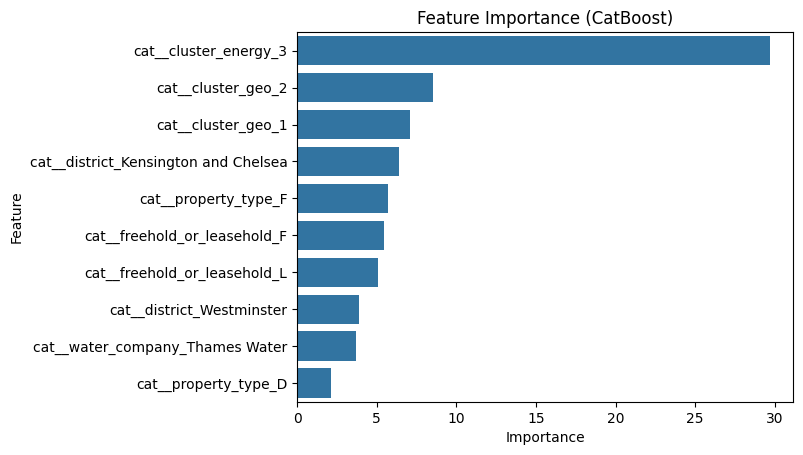

In [ ]:
#Plotting feature importance for cat boost
sns.barplot(data=feature_importance_cat.head(10),x='Importance',y='Feature')
plt.title('Feature Importance (CatBoost)')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

#Defining a function to calculate performance metrics on untransformed price 
#Ie. performance metrics on actual price data 
#Includes R squared, RMSE, MAPE, Average profit

def scores(model,Xtest, Ytest):
    #Predicting the model
    pred=model.predict(Xtest)

    #Reduce prediction array dimension if necessary
    if hasattr(pred, "ndim") and pred.ndim > 1:
        pred = pred.ravel()

    #Undoing log transformation by taking e^y_hat -1
    pred_real=np.exp(pred)-1

    #Calculating RMSE
    rmse=mean_squared_error(Ytest,pred_real)
    rmse=np.sqrt(rmse)
    rmse=round(rmse,2)

    #Calculating R squared
    r2 = r2_score(Ytest, pred_real)
    r2=round(r2,2)

    #Calculating R squared on transformed Y
    r2_log=r2_score(np.log(Ytest),pred)
    r2_log=round(r2_log,2)

    #calculating MAPE
    mape=mean_absolute_percentage_error(Ytest,pred_real)
    mape=100*round(mape,2)

    #Calculating Average profit 
    average_profit=round(np.mean((pred_real-Ytest)/Ytest),4)*100
    return (rmse, r2_log,r2,mape, average_profit)

In [ ]:
#Displaying performance metrics 

models=[lasso_best,en_best,rf_best,knn_best,knn_best2,knn_best3,gbm_best,xgb_best, cat_best]
model_names=['Lasso','Elastic Net','Random Forest','KNN (Geography)','KNN (Property features)','KNN All','GBM', 'XGB','CatBoost']

#Applying scores function on list of models
score=list(map(lambda l: scores(l,Xtest=X_test,Ytest=y_test),models))

#Transforming score tuple into a dataframe for visualisation
score_df= pd.DataFrame(score,columns=['RMSE (£)','R Squared (log Price)','R Squared (Actual)','MAPE (Actual)','Average Profit (%)'],index=model_names)
score_df

,RMSE (£),R Squared (log Price),R Squared (Actual),MAPE (Actual),Average Profit (%)
Lasso,383632.99,0.73,0.55,22.0,4.23
Elastic Net,338445.25,0.71,0.65,25.0,12.05
Random Forest,245554.27,0.85,0.81,16.0,2.37
KNN (Geography),399811.87,0.64,0.51,25.0,5.29
KNN (Property features),407861.77,0.62,0.49,25.0,4.86
KNN All,349881.64,0.75,0.62,20.0,2.50
GBM,230136.43,0.86,0.84,15.0,2.25
XGB,239208.81,0.86,0.82,15.0,2.35
CatBoost,359654.95,0.67,0.60,24.0,5.42


# Stacking

Use stacking to ensemble your algorithms.



In [ ]:
from sklearn.model_selection import cross_val_predict

#Using cross_val_predict to get CV predictions from previous models to build Stacking model
lasso_pred=cross_val_predict(lasso_best,X_train,Ytrain2, cv=5, method='predict')


en_pred=cross_val_predict(en_best,X_train,Ytrain2, cv=5,method='predict')


knn_pred=cross_val_predict(knn_best,X_train,Ytrain2, cv=5, method='predict')
knn_pred=[knn_pred[i][0] for i in range(len(knn_pred))]

knn_pred2=cross_val_predict(knn_best2,X_train,Ytrain2, cv=5, method='predict')
knn_pred2=[knn_pred2[i][0] for i in range(len(knn_pred2))]

knn_pred3=cross_val_predict(knn_best3,X_train,Ytrain2, cv=5, method='predict')
knn_pred3=[knn_pred3[i][0] for i in range(len(knn_pred3))]

rf_pred=cross_val_predict(rf_best,X_train,Ytrain2, cv=5, method='predict')

gbm_pred=cross_val_predict(gbm_best,X_train,Ytrain2, cv=5, method='predict')

gbm_pred2=cross_val_predict(gbm_best2,X_train,y_train, cv=5, method='predict')

xgb_pred=cross_val_predict(xgb_best,X_train,Ytrain2, cv=5, method='predict')

cat_pred=cross_val_predict(cat_best,X_train,Ytrain2, cv=5, method='predict')

0:	learn: 0.5345490	total: 9.01ms	remaining: 9s
1:	learn: 0.5230177	total: 11.9ms	remaining: 5.91s
2:	learn: 0.5123946	total: 13.5ms	remaining: 4.49s
3:	learn: 0.5037966	total: 14.6ms	remaining: 3.63s
4:	learn: 0.4945477	total: 16.3ms	remaining: 3.25s
5:	learn: 0.4860634	total: 17ms	remaining: 2.82s
6:	learn: 0.4782709	total: 20ms	remaining: 2.83s
7:	learn: 0.4710879	total: 20.6ms	remaining: 2.55s
8:	learn: 0.4650720	total: 21.1ms	remaining: 2.33s
9:	learn: 0.4595547	total: 21.7ms	remaining: 2.15s
10:	learn: 0.4544981	total: 22.4ms	remaining: 2.01s
11:	learn: 0.4490165	total: 23ms	remaining: 1.89s
12:	learn: 0.4440212	total: 23.6ms	remaining: 1.79s
13:	learn: 0.4397505	total: 24.2ms	remaining: 1.71s
14:	learn: 0.4354254	total: 24.8ms	remaining: 1.63s
15:	learn: 0.4314819	total: 25.6ms	remaining: 1.57s
16:	learn: 0.4278889	total: 26.1ms	remaining: 1.51s
17:	learn: 0.4244629	total: 26.8ms	remaining: 1.46s
18:	learn: 0.4213355	total: 27.4ms	remaining: 1.41s
19:	learn: 0.4184315	total: 27.

In [ ]:
#Undoing log transformation on predictions to use actual price on stacked model

lasso_pred=np.exp(lasso_pred)-1

en_pred=np.exp(en_pred)-1

knn_pred=np.exp(knn_pred)-1
knn_pred2=np.exp(knn_pred2)-1
knn_pred3=np.exp(knn_pred3)-1
rf_pred=np.exp(rf_pred)-1
gbm_pred=np.exp(gbm_pred)-1
xgb_pred=np.exp(xgb_pred)-1
cat_pred=np.exp(cat_pred)-1

Text(0.5, 1.0, 'Correlation Between Base Models')

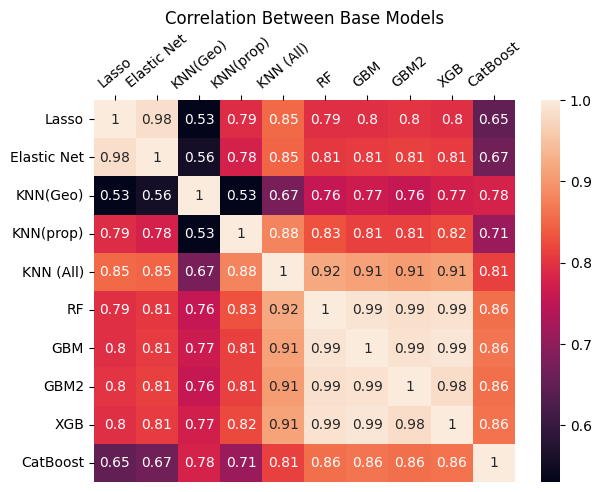

In [ ]:
#Plotting correlations between model predictions
#Getting correlation matrix between models
corr_matrix=np.corrcoef([lasso_pred,en_pred,knn_pred,knn_pred2,knn_pred3,rf_pred,gbm_pred,gbm_pred2,xgb_pred,cat_pred])
corr_df= pd.DataFrame(corr_matrix,columns=['Lasso','Elastic Net','KNN(Geo)','KNN(prop)','KNN (All)','RF','GBM','GBM2','XGB','CatBoost'],
                      index=['Lasso','Elastic Net','KNN(Geo)','KNN(prop)','KNN (All)','RF','GBM','GBM2','XGB','CatBoost'])

#Plotting heatmap of correlations
fig=sns.heatmap(corr_df, annot=True)
fig.xaxis.tick_top()
fig.set_xticklabels(fig.get_xticklabels(), rotation=40)
plt.tight_layout()
plt.title("Correlation Between Base Models")

In [ ]:
#Feature reduction using lasso regression
X_meta=np.column_stack([knn_pred2, lasso_pred,knn_pred,knn_pred3,gbm_pred,en_pred,rf_pred,xgb_pred,cat_pred])


meta_learner_lasso=Lasso()

meta_lasso=GridSearchCV(
    meta_learner_lasso,
    param_grid={'alpha':[0.1, 1, 10, 100, 1000, 10000]},
    cv=5,
    scoring='neg_root_mean_squared_error'
)


meta_lasso.fit(X_meta,y_train)

meta_lasso_best= meta_lasso.best_estimator_

#No feature reduction necessary
meta_lasso_best.coef_

array([-0.08912069,  0.22553171,  0.06836847, -0.18329014,  0.89600084,
        0.01752591, -0.03944503,  0.07797557,  0.10739258])

In [ ]:
#Selecting best models for meta-learner
#KNN (on all features), XGB, Elastic Net, RF, CatBoost, and GBM is used to train the meta-learner
X_meta_train=np.column_stack([knn_pred,xgb_pred,en_pred,rf_pred,cat_pred,gbm_pred])



In [ ]:
#GBM meta learner
meta_learner_gbm=GradientBoostingRegressor(random_state=10001)
meta_learner_gbm.fit(X_meta_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
#Linear regression meta-learner
meta_learner_linear=LinearRegression()
meta_learner_linear.fit(X_meta_train,y_train)
meta_learner_linear.coef_

array([ 0.08734694,  0.01650273,  0.17294531, -0.18743701,  0.06352755,
        0.9873948 ])

In [ ]:
from sklearn.linear_model import Ridge

#Ridge regression meta-learner
#Ridge does not automatically shrink any variables that are redundant 
#Can also handle multicollinear features 
meta_learner_ridge=Ridge(solver='sag')

#Grid search on alpha
meta_ridge=GridSearchCV(
    meta_learner_ridge,
    param_grid={'alpha':[0.1, 1, 10, 100, 1000, 10000]},
    cv=5,
    scoring='neg_root_mean_squared_error'
)

#Fitting ridge model
meta_ridge.fit(X_meta_train,y_train)

#getting best model
meta_ridge_best= meta_ridge.best_estimator_

meta_ridge_best.coef_

array([ 0.08730611,  0.01826276,  0.1729442 , -0.18695028,  0.06356017,
        0.98519858])

In [ ]:
#Defining a function for model performance metrics without undoing log transformation
def linear_metrics(model,X_test,Y_test):
    #Predict on model 
    pred=model.predict(X_test)
    
    #RMSE
    rmse=mean_squared_error(Y_test,pred)
    rmse=np.sqrt(rmse).astype(float)

    #R squared
    r2 = r2_score(Y_test, pred)

    #Put everything together in a dict 
    lr_results = {"RMSE": rmse, "Rsquare": r2}
    print("lr_results:", lr_results)

In [ ]:
#Getting predictions on test set and undoing log transformation on predicted results 

lasso_pred_test=np.exp(lasso_best.predict(X_test))-1

rf_pred_test=np.exp(rf_best.predict(X_test))-1
knn_pred_test=np.exp(knn_best.predict(X_test))-1
knn_pred_test2=np.exp(knn_best2.predict(X_test))-1
knn_pred_test3=np.exp(knn_best3.predict(X_test))-1
gbm_pred_test=np.exp(gbm_best.predict(X_test))-1
en_pred_test=np.exp(en_best.predict(X_test))-1
xgb_pred_test=np.exp(xgb_best.predict(X_test))-1
cat_pred_test=np.exp(cat_best.predict(X_test))-1

gbm_pred2_test=gbm_best2.predict(X_test)


#Column stacks for meta learners
X_meta_test=np.column_stack([knn_pred_test,xgb_pred_test,en_pred_test,rf_pred_test,cat_pred_test,gbm_pred_test])
X_meta_test2=np.column_stack([knn_pred_test2,lasso_pred_test,knn_pred_test,knn_pred_test3,en_pred_test,gbm_pred_test,rf_pred_test,xgb_pred_test,cat_pred_test])

#Performance metrics on test set for meta-learners
linear_metrics(meta_learner_gbm,X_meta_test,y_test)
linear_metrics(meta_learner_linear,X_meta_test,y_test)
linear_metrics(meta_ridge_best,X_meta_test,y_test)

lr_results: {'RMSE': np.float64(235876.36437409732), 'Rsquare': 0.8291755928467349}
lr_results: {'RMSE': np.float64(219766.68278052428), 'Rsquare': 0.8517124201077719}
lr_results: {'RMSE': np.float64(219763.5455223753), 'Rsquare': 0.8517166538077299}


In [ ]:
#Defining function to get performance metrics without y transformation

def scores2(model,Xtest, Ytest):
    #Get predictions
    pred=model.predict(Xtest)

    #RMSE
    rmse=mean_squared_error(Ytest,pred)
    rmse=np.sqrt(rmse)
    rmse=round(rmse,2)

    #R squared
    r2 = r2_score(Ytest, pred)
    r2=round(r2,2)

    #MAPE
    mape=mean_absolute_percentage_error(Ytest,pred)
    mape=100*round(mape,2)

    #Average Profit
    avg_profit=100*round(np.mean((pred-Ytest)/Ytest),2)
    return (rmse, r2, mape,avg_profit)

In [ ]:
#Comparing meta-learner performance on test set
models=[meta_learner_gbm,meta_learner_linear,meta_ridge_best]
model_names=['GBM Meta Learner','Linear Meta Learner','Ridge']

#Mapping scores onto meta-learners
score=list(map(lambda l: scores2(l,Xtest=X_meta_test,Ytest=y_test),models))

#Displaying dataframe 
score_df= pd.DataFrame(score,columns=['RMSE','R Squared','MAPE','Average Profit'],index=model_names)
score_df

,RMSE,R Squared,MAPE,Average Profit
GBM Meta Learner,235876.36,0.83,16.0,5.0
Linear Meta Learner,219766.68,0.85,16.0,3.0
Ridge,219763.55,0.85,16.0,3.0


In [ ]:
#Comparing meta-learner performance on train set to check for overfitting
score=list(map(lambda l: scores2(l,Xtest=X_meta_train,Ytest=y_train),models))

score_df= pd.DataFrame(score,columns=['RMSE','R Squared','MAPE','Average Profit'],index=model_names)
score_df

,RMSE,R Squared,MAPE,Average Profit
GBM Meta Learner,133987.02,0.93,15.0,4.0
Linear Meta Learner,183804.46,0.87,16.0,3.0
Ridge,183804.48,0.87,16.0,3.0


In [ ]:
#Getting base-learner weights in Ridge meta-learner
meta_ridge_coef=meta_ridge_best.coef_
name_models=['KNN','XGB','Elastic Net','Random Forest','CatBoost','GBM']
coefs=[]

for coef in meta_ridge_coef:
    coefs.append(coef)

coefs_df=pd.DataFrame({'Base Learner':name_models,'Weight':coefs})
coefs_df.sort_values(by='Weight', ascending=False)


,Base Learner,Weight
5,GBM,0.985199
2,Elastic Net,0.172944
0,KNN,0.087306
4,CatBoost,0.063560
1,XGB,0.018263
3,Random Forest,-0.186950


# Pick investments

In this section you should use the best algorithm you identified to choose 200 properties from the out of sample data.

In [ ]:
#Creating clustered columns on oos data
df4=london_house_prices_2019_out_of_sample.copy()
df3 = london_house_prices_2019_training.copy()

#Clsutering for energy features
scaler=StandardScaler()

energy_features=['total_floor_area','co2_emissions_current','co2_emissions_potential','energy_consumption_potential','energy_consumption_current']

#Scaling on training data
df3_scaled_energy=scaler.fit_transform(df3[energy_features])

#Scaling on OOS
df4_scaled_energy=scaler.transform(df4[energy_features])

#Fitting K-means on training data
km_energy=KMeans(n_clusters=3,n_init=50, random_state=1).fit(df3_scaled_energy)

#Predicting Kmeans on OOS
km_predict_energy=km_energy.predict(df4_scaled_energy)+1

#Adding labels to OOS dataframe
df4['cluster_energy']=km_predict_energy



In [282]:
#Clustering on geographic features
geo_features=['latitude','longitude','london_zone','distance_to_station']

#Scaling data
df3_scaled_geo=scaler.fit_transform(df3[geo_features])
df4_scaled_geo=scaler.transform(df4[geo_features])

#Fitting K-means clustering
km_geo=KMeans(n_clusters=2,n_init=50, random_state=1).fit(df3_scaled_geo)
km_predict_geo=km_geo.predict(df4_scaled_geo)+1

#Adding labels to OOS dataframe
df4['cluster_geo']=km_predict_geo

In [ ]:
#Predicting on OOS using ridge model
#Creating stacked columns for prediction
ridge_models=[knn_best,en_best,rf_best,gbm_best,cat_best,xgb_best]
columns=[]

for model in ridge_models:
    pred=np.exp(model.predict(df4))-1
    columns.append(pred)

stack_oos=np.column_stack([col for col in columns])


In [ ]:
#Getting predictions and generating list of investments
pred_oos=pd.DataFrame({'ID':df4['ID'],'asking price':df4['asking_price'],'price':meta_ridge_best.predict(stack_oos)})

#Calculating price difference between asking price and predicted price 
pred_oos['price_diff']=(pred_oos['price']-pred_oos['asking price'])/pred_oos['asking price']

#Selecting the top 200 most undervalued properties 
pred_oos_ranked=pred_oos.sort_values(by='price_diff', ascending=False).head(200)
pred_oos_ranked

,ID,asking price,price,price_diff
25,5977,192000.0,944563.657516,3.919602
881,7296,112000.0,429533.265318,2.835118
863,9101,83000.0,315725.154937,2.803918
38,15713,84000.0,284379.974546,2.385476
1400,8684,131000.0,376109.347261,1.871064
...,...,...,...,...
1015,4808,596000.0,785174.018509,0.317406
415,4494,291000.0,383305.846853,0.317202
8,9363,534000.0,702992.307210,0.316465
73,12103,453000.0,596153.194219,0.316011


In [289]:
#Calculating Average profit %
average_profit= np.mean(pred_oos_ranked['price_diff'])*100
print(f'The average profit % is {average_profit:.2f}%')
print(f'There are {len(pred_oos_ranked)} investments in the portfolio')

The average profit % is 65.75%
There are 200 investments in the portfolio


In [ ]:
#Creating buy column for investments
df4['buy']=df4['ID'].isin(pred_oos_ranked['ID']).astype(int)
df4


,ID,date,postcode,property_type,whether_old_or_new,freehold_or_leasehold,address1,address2,address3,town,local_aut,county,postcode_short,current_energy_rating,total_floor_area,number_habitable_rooms,co2_emissions_current,co2_emissions_potential,energy_consumption_current,energy_consumption_potential,windows_energy_eff,tenure,latitude,longitude,population,altitude,london_zone,nearest_station,water_company,average_income,district,type_of_closest_station,num_tube_lines,num_rail_lines,num_light_rail_lines,distance_to_station,asking_price,cluster_energy,cluster_geo,buy
0,14434,NaT,NaN,D,N,F,NaN,NaN,NaN,NaN,NaN,NaN,N14,D,150.0,6,7.3,2.4,274,89,Average,owner-occupied,51.624538,-0.129001,87.0,63,4,arnos grove,Thames Water,61300,Enfield,tube,1,0,0,0.838890,750000.0,3,2,0
1,12562,NaT,NaN,F,N,L,NaN,NaN,NaN,NaN,NaN,NaN,HA0,C,59.0,2,1.5,1.4,142,136,Average,owner-occupied,51.551654,-0.296625,79.0,38,4,wembley central,Affinity Water,48900,Brent,tube,2,1,1,0.103774,229000.0,2,1,0
2,8866,NaT,NaN,F,N,L,NaN,NaN,NaN,NaN,NaN,NaN,E3,D,58.0,2,2.8,1.2,253,110,Average,owner-occupied,51.536359,-0.032838,23.0,17,2,hackney wick,Thames Water,46200,Tower Hamlets,light_rail,0,0,1,0.914079,152000.0,2,1,1
3,10721,NaT,NaN,S,N,F,NaN,NaN,NaN,NaN,NaN,NaN,HA2,D,74.0,5,3.5,1.2,256,80,Average,owner-occupied,51.559214,-0.374416,73.0,39,5,northolt park,Affinity Water,52200,Harrow,rail,0,1,0,0.765565,379000.0,2,2,0
4,1057,NaT,NaN,T,N,F,NaN,NaN,NaN,NaN,NaN,NaN,W4,E,97.3,5,6.5,5.7,303,266,Average,owner-occupied,51.491380,-0.257589,100.0,8,2,turnham green,Thames Water,60700,Hounslow,tube,2,0,0,0.448651,930000.0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,3690,NaT,NaN,D,N,F,NaN,NaN,NaN,NaN,NaN,NaN,HA4,F,79.0,4,8.9,3.2,622,214,Poor,owner-occupied,51.583597,-0.430962,8.0,54,6,ruislip,Affinity Water,60400,Hillingdon,tube,2,0,0,0.970005,718000.0,1,2,0
1995,9181,NaT,NaN,S,N,F,NaN,NaN,NaN,NaN,NaN,NaN,HA4,C,153.0,7,4.3,2.9,158,107,Good,owner-occupied,51.575697,-0.389457,79.0,44,5,eastcote,Affinity Water,64600,Hillingdon,tube,2,0,0,0.494013,903000.0,2,2,0
1996,11246,NaT,NaN,F,N,L,NaN,NaN,NaN,NaN,NaN,NaN,SE1,C,81.0,2,2.1,2.2,172,177,Good,owner-occupied,51.502170,-0.098875,34.0,9,1,borough,Thames Water,56600,Southwark,tube,1,0,0,0.360412,556000.0,2,1,0
1997,1247,NaT,NaN,S,N,F,NaN,NaN,NaN,NaN,NaN,NaN,SE21,D,82.0,4,3.4,1.3,276,116,Poor,owner-occupied,51.450050,-0.086822,62.0,30,2,north dulwich,Thames Water,76600,Southwark,rail,0,1,0,0.461700,1131000.0,2,1,0


In [291]:
df4.to_csv('chong_christie.csv',index=False)